# Pyrace Assignment – Part 2 (V1 vs V2 Comparison)

## Discussion: Possible Ways of Improving the Model

The original V1 environment provides a simple baseline for training a DQN agent, but it also has several limitations that may restrict learning quality. In particular, the observations are discretized, the action space is limited, and the reward function is relatively sparse. These design choices simplify the problem, but they may also prevent the agent from learning more precise and informative driving behavior.

The performance of a reinforcement learning agent depends heavily on three elements: the quality of the observations (state), the available actions, and the reward function. In the original V1 environment, each of these components introduces limitations that may hinder learning:
- First, the observations are discretized. This reduces the precision of the information available to the agent, meaning that small but important differences in distance or position may be lost. As a result, the agent may struggle to learn fine-grained control policies, since different states can appear identical after discretization.
- Second, the action space is limited. With only acceleration and turning actions, the agent has no direct way to control its speed in a precise manner. This restricts the range of behaviors it can learn, particularly in situations where slowing down would help avoid collisions or navigate turns more effectively.
- Third, the reward function in V1 is sparse. The agent primarily receives feedback only at terminal states (goal or crash), which makes learning difficult because it does not provide guidance during intermediate steps. This can lead to slow convergence and unstable behavior.

To address these limitations, a second version of the environment was created. The goal of V2 was to provide the agent with richer information from the environment, more control flexibility, and a reward function that better reflects meaningful progress on the track:

- Continuous observations provide more precise state information, allowing the agent to distinguish between similar situations.
- An additional brake action increases control flexibility, enabling more nuanced driving behavior.
- A redesigned reward function introduces intermediate feedback, rewarding progress and guiding the agent toward better policies.

These modifications were intended to help the agent learn more effectively and develop a stronger driving policy. The following sections describe these changes and compare the performance of V1 and V2.

## 1. Changes Introduced in V2

**Observations:**
- V1: Radar distances discretized into integer values
- V2: Radar distances returned as continuous floating-point values

**Actions:**
- V1: 3 actions (accelerate, turn left, turn right)
- V2: 4 actions (added a brake action)

**Reward Function:**
- V1: Sparse reward (large positive reward for goal, large negative reward for crash)
- V2: Engineered reward including:
  - Bonus for reaching checkpoints
  - Reward based on progress toward the next checkpoint
  - Small step penalty to discourage unnecessarily long episodes
  - Penalties/rewards for crash and goal

## 2. Load Training Results

First we load the saved reward histories for both V1 and V2. The comparison below uses the reward arrays saved after **5,000 training episodes**, since this provides a clear view of the performance difference between the two versions.

In [40]:
import numpy as np
import matplotlib.pyplot as plt

EPISODE_V1 = 5000
EPISODE_V2 = 5000

rewards_v1 = np.load(f'models_DQN_v01/rewards_{EPISODE_V1}.npy')
rewards_v2 = np.load(f'models_DQN_v02/rewards_{EPISODE_V2}.npy')

print(f'V1 rewards loaded: {rewards_v1.shape}')
print(f'V2 rewards loaded: {rewards_v2.shape}')

V1 rewards loaded: (5000,)
V2 rewards loaded: (5000,)


## 3. Training Comparison (5,000 Episodes)

Then we compare the training performance of V1 and V2 by visualizing their reward progression over the first 5,000 episodes. The reward curves provide insight into learning behavior, convergence trends, and the differences in performance between the two approaches.

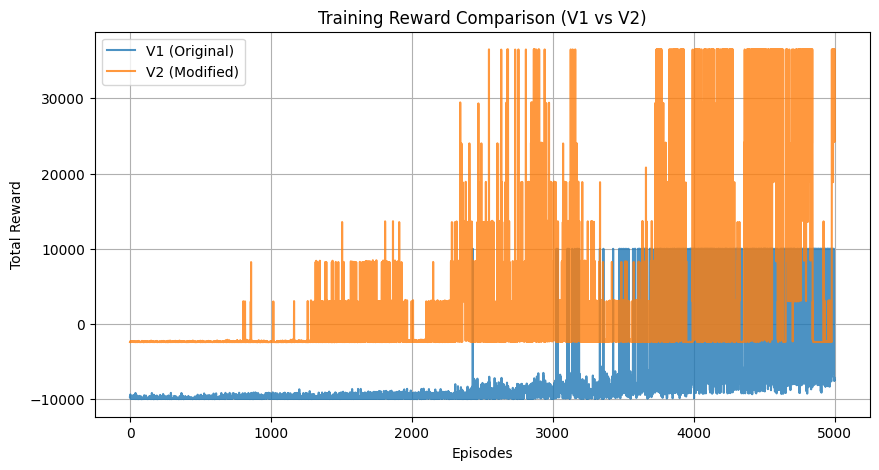

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(rewards_v1, label='V1 (Original)', alpha=0.8)
plt.plot(rewards_v2, label='V2 (Modified)', alpha=0.8)

plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Training Reward Comparison (V1 vs V2)')
plt.legend()
plt.grid(True)

plt.show()

The training results at 5,000 episodes show a clear difference between the two versions.

The V2 agent achieves significantly higher rewards earlier in training, indicating faster learning and more effective use of the reward signal. In contrast, the V1 agent remains mostly in the negative reward range for a longer period, suggesting frequent crashes and slower learning.

Overall, V2 demonstrates improved learning efficiency compared to V1 during the early stages of training.

## 4. Evaluation (No Exploration)

Both trained agents are evaluated without exploration. This means that the agents act greedily by always selecting the action with the highest predicted Q-value.

Testing without exploration makes it possible to compare the learned policies directly and observe how well each version performs after training.

## 4.1 Recreate the Agents and Load Saved Checkpoints

The following cells recreate lightweight evaluation versions of the DQN agents and load the saved checkpoints for both V1 and V2.

In [42]:
import os
import random
from collections import deque

import gymnasium as gym
import gym_race

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    BACKEND = 'torch'
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers
    BACKEND = 'keras'
    
LEARNING_RATE = 1e-3
MEMORY_SIZE = 50_000
CHECKPOINT_V1 = 5000
CHECKPOINT_V2 = 5000

def build_model_torch(state_size, action_size):
    model = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_size),
    )
    return model

def build_model_keras(state_size, action_size):
    model = keras.Sequential([
        layers.Input(shape=(state_size,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(action_size, activation='linear'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='mse'
    )
    return model

class ReplayBuffer:
    def __init__(self, capacity=MEMORY_SIZE):
        self.buffer = deque(maxlen=capacity)

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = ReplayBuffer(MEMORY_SIZE)

        if BACKEND == 'torch':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.model = build_model_torch(state_size, action_size).to(self.device)
        else:
            self.model = build_model_keras(state_size, action_size)

    def select_action(self, state, explore_rate):
        if random.random() < explore_rate:
            return random.randrange(self.action_size)
        return self._predict_best_action(state)

    def _predict_best_action(self, state):
        s = np.array(state, dtype=np.float32)

        if BACKEND == 'torch':
            with torch.no_grad():
                t = torch.FloatTensor(s).unsqueeze(0).to(self.device)
                q = self.model(t)
            return int(q.argmax().item())
        else:
            q = self.model.predict(s.reshape(1, -1), verbose=0)
            return int(np.argmax(q[0]))

    def load(self, path):
        if BACKEND == 'torch':
            self.model.load_state_dict(torch.load(path, map_location='cpu'))
            self.model.eval()
        else:
            from tensorflow import keras as _k
            self.model = _k.models.load_model(path)

env_v1 = gym.make('Pyrace-v1').unwrapped
env_v2 = gym.make('Pyrace-v2').unwrapped

agent_v1 = DQNAgent(env_v1.observation_space.shape[0], env_v1.action_space.n)
agent_v2 = DQNAgent(env_v2.observation_space.shape[0], env_v2.action_space.n)

path_model_v1 = f'models_DQN_v01/dqn_{CHECKPOINT_V1}.pth' if BACKEND == 'torch' else f'models_DQN_v01/dqn_{CHECKPOINT_V1}.keras'
path_model_v2 = f'models_DQN_v02/dqn_{CHECKPOINT_V2}.pth' if BACKEND == 'torch' else f'models_DQN_v02/dqn_{CHECKPOINT_V2}.keras'

agent_v1.load(path_model_v1)
agent_v2.load(path_model_v2)

print("Loaded V1 model from:", path_model_v1)
print("Loaded V2 model from:", path_model_v2)

init
init v2
Loaded V1 model from: models_DQN_v01/dqn_5000.pth
Loaded V2 model from: models_DQN_v02/dqn_5000.pth


In [43]:
def evaluate(env_name, agent, episodes=10, max_steps=2000):
    env = gym.make(env_name).unwrapped
    results = []

    for _ in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):
            action = agent.select_action(state, explore_rate=0.0)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

            if done:
                break

        results.append(total_reward)

    return np.mean(results), results

In [44]:
avg_v1, results_v1 = evaluate('Pyrace-v1', agent_v1)
avg_v2, results_v2 = evaluate('Pyrace-v2', agent_v2)

print("V1 average reward:", avg_v1)
print("V2 average reward:", avg_v2)

init
init v2
V1 average reward: -7066.0
V2 average reward: 26146.174270627344


### Evaluation Results

Both trained agents were evaluated with exploration disabled (`epsilon = 0`) so that each agent followed its learned policy greedily.

- **V1 average reward:** -7066.0
- **V2 average reward:** 26146.17

The evaluation results confirm the trend observed in the training curves. V2 performs substantially better than V1 when both agents act without exploration, indicating that the modified environment led to a much stronger learned policy.

## 5. Results Summary

The following table summarizes the observed performance of both agents based on the training curves and direct evaluation.

| Metric        | V1 (Original)                              | V2 (Modified)                                      |
|--------------|---------------------------------------------|----------------------------------------------------|
| Avg Reward   | -7066.0                                     | 26146.17                                           |
| Stability    | Consistently poor performance               | Consistently strong performance                    |
| Crash Rate   | High, with frequent early failure           | Much lower, with successful sustained performance  |
| Progress     | Limited progress                            | Strong progress toward checkpoints and goal        |

## 6. Conclusion

The modified V2 environment improved performance substantially compared to the original V1 implementation.

In the training comparison at 5,000 episodes, V2 reached significantly higher rewards much earlier than V1, indicating faster and more effective learning. This trend was also confirmed during direct evaluation with exploration disabled. V1 achieved an average reward of **-7066.0**, while V2 achieved an average reward of **26146.17**, showing a very large performance gap in favor of V2.

The main factors contributing to this improvement are likely the more informative reward structure and the richer observation space. Continuous radar values provide more precise information to the agent, while the engineered reward function gives denser feedback during training. The additional brake action also increases control flexibility, allowing the agent to respond more effectively to the environment.

Overall, the V2 modifications successfully improved learning performance and driving behavior compared to V1.

## 7. Bonus: Exploring a More Advanced Reinforcement Learning Algorithm

The previous sections compared two DQN-based approaches: the original environment (V1) and the modified environment (V2). As an additional extension, a more advanced reinforcement learning algorithm is now tested.

This bonus part is intended to explore algorithms beyond the original DQN approach, especially by taking advantage of the fact that the environment is compatible with Gymnasium. This makes it possible to test more advanced reinforcement learning methods using external frameworks such as Stable-Baselines3.

In this section, **PPO (Proximal Policy Optimization)** is selected as the advanced algorithm. PPO is a policy-gradient method that directly learns a policy, rather than estimating Q-values as in DQN. It is widely used because of its stability and strong performance across many environments.

The purpose of this bonus section is to evaluate whether PPO can achieve stronger or more stable performance than the DQN-based V2 approach.

### Why PPO Was Chosen

PPO was selected because it is easier to apply in this setting than methods such as DDPG. The current Pyrace environment uses a **discrete action space**, and PPO can handle this naturally. In contrast, DDPG is generally designed for continuous action spaces and would require a different environment design.

PPO is also appropriate here because:

- it is known to be more stable than many earlier policy-gradient methods,
- it is straightforward to train using Stable-Baselines3,
- and it provides a useful comparison against DQN, since it learns through a different optimization strategy.

Testing PPO therefore makes it possible to analyze whether the performance of the agent can be improved not only by changing the environment, but also by changing the learning algorithm itself.

In [ ]:
!pip install stable-baselines3

### PPO Training Setup

The PPO agent is trained on the modified `Pyrace-v2` environment. Since PPO is implemented in Stable-Baselines3, the environment is created using the Gymnasium-compatible interface.

The policy used is `MlpPolicy`, which is appropriate for vector-based observations such as radar inputs. The model is then trained for a fixed number of timesteps and saved for later evaluation.

In [46]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create environment
env = make_vec_env('Pyrace-v2', n_envs=1)

# Create PPO model
model = PPO("MlpPolicy", env, verbose=1)

# Train
model.learn(total_timesteps=100_000)

# Save model
model.save("ppo_pyrace_v2")

c:\Users\hibba\Downloads\RLI_17-Assignment\RLI_17_A0\.venv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes (['human']).
  logger.warn(


init v2
Using cpu device
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 63.2      |
|    ep_rew_mean     | -2.35e+03 |
| time/              |           |
|    fps             | 320       |
|    iterations      | 1         |
|    time_elapsed    | 6         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 78.7         |
|    ep_rew_mean          | -2.34e+03    |
| time/                   |              |
|    fps                  | 282          |
|    iterations           | 2            |
|    time_elapsed         | 14           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0071627405 |
|    clip_fraction        | 0.00381      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance

### PPO Evaluation

After training, the PPO agent is evaluated on `Pyrace-v2` using deterministic predictions. This means that the model selects the action preferred by its learned policy at each step.

The average reward over multiple episodes is used as the main evaluation metric.

In [47]:
import gymnasium as gym
import numpy as np

def evaluate_ppo(model, env_name, episodes=10, max_steps=2000):
    env = gym.make(env_name).unwrapped
    results = []

    for _ in range(episodes):
        obs, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = env.step(action)
            total_reward += reward

            if done:
                break

        results.append(total_reward)

    return np.mean(results), results

In [51]:
avg_ppo, results_ppo = evaluate_ppo(model, 'Pyrace-v2')

print("PPO average reward:", avg_ppo)

init v2
PPO average reward: 3152.927156369534


### PPO Results

**PPO average reward:** 3152.93

Although PPO achieved a positive average reward, its performance was lower than the DQN agent trained on the same modified environment.

### Updated Summary Table

After obtaining the PPO result, the summary table can be extended as follows:
| Metric        | V1 (DQN) | V2 (DQN) | PPO |
|--------------|----------|----------|-----|
| Avg Reward   | -7066.0  | 26146.17 | 3152.93 |
| Stability    | Poor     | Strong   | Moderate |
| Crash Rate   | High     | Low      | Lower than V1, but worse than V2 |
| Progress     | Limited  | Strong   | Positive progress, but clearly below V2 |

### Conclusion of Bonus Section

PPO achieved an average reward of **3152.93** on `Pyrace-v2`. Compared with the V2 DQN result of **26146.17**, this indicates that **PPO performed worse than the DQN agent trained on the modified environment**.

This suggests that, for this task, the main performance gain came from the redesign of the environment and reward structure rather than from replacing DQN with a more advanced algorithm.

Overall, the bonus experiment shows that a more advanced algorithm does not automatically guarantee better performance. In this case, PPO produced some improvement over the original baseline, but it did not exceed the performance of the modified DQN solution.